## Esercitazione 14 Aprile 2026

## Scrivere la function `NewtonRaphson.py`
che implementa il metodo di Newton-Raphson
per il calcolo della soluzione di un sistema di equazioni non lineari. 

Tale function
deve assumere come dati in input:
- fname: nome della funzione vettoriale di cui calcolare lo zero;
- JacName: nome della funzione che calcola lo Jacobiano della funzione vettoriale;
- X0: vettore contenente le componenti dell'iterato iniziale);
- tolx tolleranza  per il test d'arresto sull'incremento
        ||X_{k+1}-X_k||/||X_{k}||<= tolx
- tolf tolleranza per il test del residuo
        ||F(Xk+1)|| <= tolf;
- NMAX numero massimo di iterazioni.

In output devono essere restituiti il vettore contenente l'approssimazione dello zero x, un vettore contenente l'errore relativo tra due iterati successivi, il numero di iterazioni effettuate, nit.


Implementare in altre due function `NewtonRaphson_Corde.py` e `NewtonRaphson_Sham.py` le varianti Corde e la variante di  Shamanskii


## Esercizio 1

Risolvere i seguenti cinque sistemi non lineari con tutti e tre i metodi studiati e confrontare, in **scala logaritmica**, l’errore relativo tra due iterati successivi.

### Sistemi assegnati

**1)**  
 
\begin{cases}
2x_0 - \cos(x_1) = 0 \\
\sin(x_0) + 2x_1 = 0
\end{cases}
 

**2)**  
 
\begin{cases}
x_0^2 + x_1^2 - 4 = 0 \\
x_0^2 - x_1^2 - 1 = 0
\end{cases}
 

**3)**  
 
\begin{cases}
x_0^2 + x_1^2 - 2 = 0 \\
e^{x_0 - 1} + x_1^3 - 3 = 0
\end{cases}
 

**4)**  
 
\begin{cases}
4x_0^2 + x_1^2 - 4 = 0 \\
x_0 + x_1 - \sin(x_0 - x_1) = 0
\end{cases}
 

**5)**  
 
\begin{cases}
x_0 + x_1 - 3 = 0 \\
x_0^2 + x_1^2 - 9 = 0
\end{cases}
 
### Scelta dell’iterato iniziale

Per determinare l’iterato iniziale $X^{(0)}$, servirsi del **metodo grafico** per individuare un punto iniziale nell’intorno della soluzione che si vuole approssimare.

In particolare:

- visualizzare le **curve di livello corrispondenti a \(z=0\)** delle due superfici
$$
  z = f_1(x_0, x_1), \qquad z = f_2(x_0, x_1)
  $$
- individuare i **punti di intersezione** tra tali curve;
- scegliere come iterato iniziale un vettore
  $$
  X^{(0)} = \begin{pmatrix} x_0^{(0)} \\ x_1^{(0)} \end{pmatrix}
  $$
  le cui componenti appartengano a un intorno della soluzione desiderata.

### Obiettivo

Per ciascun sistema:

1. determinare graficamente un opportuno iterato iniziale $(X^{(0)}$);
2. applicare tutti e tre i metodi;
3. confrontare l’andamento dell’errore relativo tra due iterati successivi;
4. rappresentare tale errore in **scala logaritmica**.

In [1]:
from mpl_toolkits.mplot3d import Axes3D
import sympy as sym
import numpy as np
import matplotlib.pyplot as plt

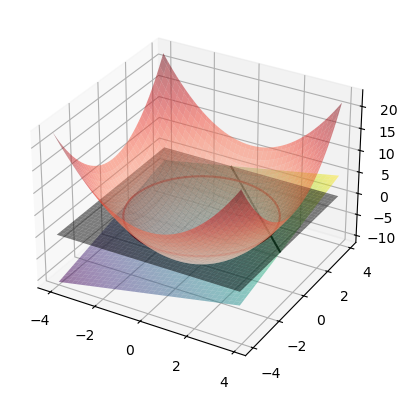

In [2]:
# Definizione variabili simboliche
x_sym, y_sym = sym.symbols('x_sym y_sym')

f1_sym = lambda x_sym,y_sym: x_sym+y_sym-3   
f2_sym= lambda x_sym,y_sym: x_sym**2+y_sym**2-9


def F_sym(f1_sym,f2_sym):
    return sym.Matrix([[f1_sym(x_sym,y_sym)], [f2_sym(x_sym,y_sym)]]) 

# Converte il vettore di funzioni Simbolico in una funzione che può essere valutata numericamente mediante lambdify
F_numerical = sym.lambdify([x_sym, y_sym], F_sym(f1_sym,f2_sym), np)


# Calcolo della matrice Jacobiana simbolicamente
J_sym = F_sym(f1_sym,f2_sym).jacobian(sym.Matrix([x_sym, y_sym]))

# Converte la matrice jacobiana Simbolica in una funzione che può essere valutata numericamente mediante lambdify
J_numerical = sym.lambdify([x_sym, y_sym], J_sym, np)


#Disegnare le superfici

# Creazione dei vettori x e y nell'intervallo [-4, 4] con passo 0.1
x = np.arange(-4, 4, 0.1)
y = np.arange(-4, 4, 0.1)

# Creazione della griglia 2D di punti (X, Y)
# X e Y contengono tutte le combinazioni possibili di x e y
X, Y = np.meshgrid(x, y)

# Creazione del piano z = 0 (stessa dimensione della griglia)
Z = np.zeros_like(X)

# Valutazione del sistema non lineare sui punti della griglia
# F_numerical restituisce un vettore con due componenti:
# superfici[0,:,:] = f1(X,Y)
# superfici[1,:,:] = f2(X,Y)
superfici = F_numerical(X, Y).squeeze()

# Creazione della figura 3D
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

# Plot della prima superficie z = f1(x,y)
ax.plot_surface(X, Y, superfici[0,:,:], cmap='viridis', alpha=0.5)

# Plot della seconda superficie z = f2(x,y)
ax.plot_surface(X, Y, superfici[1,:,:], cmap='Reds', alpha=0.5)

# Plot del piano z = 0 (serve per visualizzare dove le superfici si annullano)
ax.plot_surface(X, Y, Z, cmap='gray', alpha=0.5)

# Curve di livello z = 0 della prima funzione (f1(x,y) = 0)
plt.contour(X, Y, superfici[0,:,:], levels=[0], colors='black')

# Curve di livello z = 0 della seconda funzione (f2(x,y) = 0)
plt.contour(X, Y, superfici[1,:,:], levels=[0], colors='red')

# Mostra il grafico
plt.show()

In [81]:
def newton_raphson(initial_guess, F_num, J_num, tolx, tolf, max_it):
    X = np.array(initial_guess)

    it = 0
    erroreF = 1 + tolf
    erroreX = 1 +tolx
    errore=[]
    #update = 5
    
    while it < max_it and erroreF >= tolf and erroreX >= tolx:
        #if it % update == 0:
        jx = np.array(J_num(X[0], X[1]))
        if np.linalg.matrix_rank(jx) < jx.shape[0]:
            print("La matrice Jacobiana non ha rango massimo")
            return None, None, None

        fx = np.array(F_num(X[0], X[1])).squeeze()

        #risolviamo il sistema J(Xk) sk = -F(Xk)
        s = np.linalg.solve(jx, -fx)

        #aggiornare l'iterato
        Xnew = X + s

        normaXnew = np.linalg.norm(Xnew, 1)
        if normaXnew != 0:
            erroreX = np.linalg.norm(s, 1) / normaXnew
        else:
            erroreX = np.linalg.norm(s, 1)

        errore.append(erroreX)
        fXnew = np.array(F_num(Xnew[0], Xnew[1])).squeeze()
        erroreF = np.linalg.norm(fXnew, 1)

        #aggiorno l'iterato corrente
        X = Xnew
        it = it + 1

    return X, it, errore

In [82]:
tolX = 1e-10
tolF = 1e-10
max_it = 100
initial_guess = [-1, 1]
Xs, it, errore = newton_raphson(initial_guess, F_numerical, J_numerical, tolX, tolF, max_it)

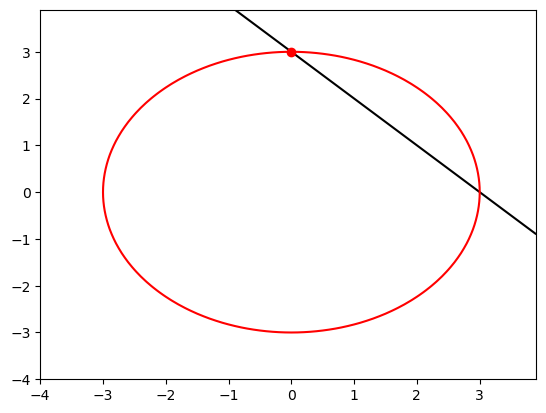

In [83]:
# Curve di livello z = 0 della prima funzione (f1(x,y) = 0)
plt.contour(X, Y, superfici[0,:,:], levels=[0], colors='black')

# Curve di livello z = 0 della seconda funzione (f2(x,y) = 0)
plt.contour(X, Y, superfici[1,:,:], levels=[0], colors='red')

plt.plot(Xs[0], Xs[1], 'ro')
# Mostra il grafico
plt.show()

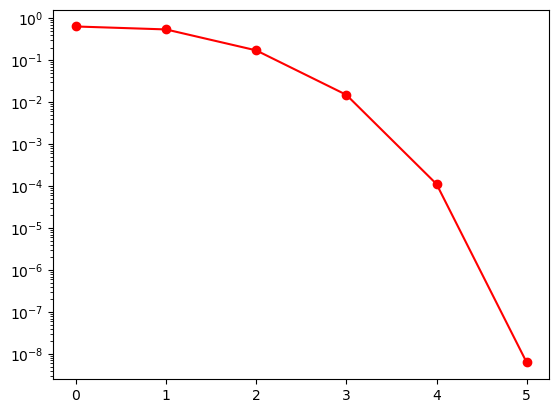

In [84]:
plt.semilogy(np.arange(it), errore, 'ro-')

## Esercizio 2
Implementare il metodo di Newton Raphson per il calcolo del minimo assoluto (relativo) di una funzione non lineare.

Calcolare il punto di minimo delle seguenti tre funzioni 
   $$\frac{1}{2}(0.001(x-1)^2+(x^2-y)^2), \quad \alpha=[1,1], x0=[-3,-3]$$
   $$ (x - 2)^4 + (x - 2)^2 y^2+(y+1)^2 \quad \alpha=[2,-1], x0=[1,1]$$
   $$x^4+(x+y)^2y^2+(exp(x)-1)^2  \quad \alpha=[0,0], x0=[-1,3]$$
   $$100(y-x^2)^2+(1-x)^2  \quad \alpha=[1,1], x0=[-1.9,2]$$

In [85]:
F_sym = 0.5 * (0.001 * (x_sym - 1)**2 + (x_sym**2 - y_sym)**2)

#Calcolo del vettore gradiente simbolicamente
grad_f = sym.derive_by_array(F_sym, (x_sym,y_sym))
#Calcolo della matrice Hessiana simbolicamente
H = sym.hessian(F_sym, (x_sym,y_sym))# Conversione delle espressioni simboliche in funzioni numeriche
grad_f_func = sym.lambdify((x_sym,y_sym), grad_f, np)
H_func = sym.lambdify((x_sym,y_sym), H, np)
F_func=sym.lambdify((x_sym,y_sym), F_sym, np)
H = sym.hessian(F_sym, (x_sym,y_sym))

# Conversione delle espressioni simboliche in funzioni numeriche
grad_f_numerical = sym.lambdify((x_sym,y_sym), grad_f, 'numpy')
H_numerical = sym.lambdify((x_sym,y_sym), H, 'numpy')
F_numerical=sym.lambdify((x_sym,y_sym), F_sym, 'numpy')

In [91]:
def newton_raphson_minimo(initial_guess, grad_f_numerical, H_numerical, tolx, tolf, max_it):
    X = np.array(initial_guess)

    it = 0
    erroreF = 1 + tolf
    erroreX = 1 +tolx
    errore=[]
    #update = 5
    
    while it < max_it and erroreF >= tolf and erroreX >= tolx:
        #if it % update == 0:
        hx = np.array(H_numerical(X[0], X[1]))
        if np.linalg.matrix_rank(hx) < hx.shape[0]:
            print("La matrice Jacobiana non ha rango massimo")
            return None, None, None

        gfx = np.array(grad_f_numerical(X[0], X[1])).squeeze()

        #risolviamo il sistema H(Xk) sk = - grad F(Xk)
        s = np.linalg.solve(hx, -gfx)

        #aggiornare l'iterato
        Xnew = X + s

        normaXnew = np.linalg.norm(Xnew, 1)
        if normaXnew != 0:
            erroreX = np.linalg.norm(s, 1) / normaXnew
        else:
            erroreX = np.linalg.norm(s, 1)

        errore.append(erroreX)
        
        gfXnew = np.array(grad_f_num(Xnew[0], Xnew[1])).squeeze()
        erroreF = np.linalg.norm(gfXnew, 1)

        #aggiorno l'iterato corrente
        X = Xnew
        it = it + 1

    return X, it, errore

In [92]:
#Disegnare le superfici

# Creazione dei vettori x e y nell'intervallo [-4, 4] con passo 0.1
x = np.arange(-4, 4, 0.1)
y = np.arange(-4, 4, 0.1)

# Creazione della griglia 2D di punti (X, Y)
# X e Y contengono tutte le combinazioni possibili di x e y
X, Y = np.meshgrid(x, y)

ValueError: Argument Z must be 2-dimensional.

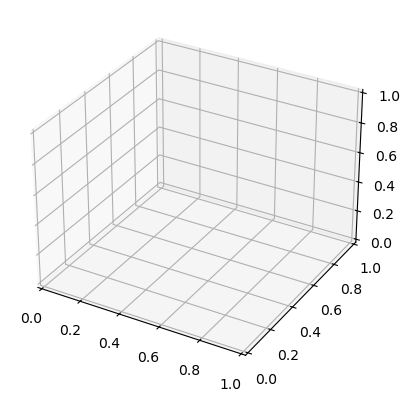

In [96]:
Z = F_numerical(x, y)

# Creazione della figura 3D
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

# Plot del piano z = 0 (serve per visualizzare dove le superfici si annullano)
ax.plot_surface(X, Y, Z, cmap='gray', alpha=0.5)

# Esercizio 3
- Costruire la matrice di Vandermonde A, generata dal vettore x=[1.0,2.0,...,6.0] utilizzando la funzione np.vander(x, increasing=True) di numpy. 
- Calcolarne l'indice di condizionamento in norma infinito senza utilizzare la funzione cond di numpy.linalg e poi confrontarne il valore con quello ottenuto utilizzando la funzione.
- Considerare il sistema lineare Ax=b  con matrice dei coefficienti A e termine noto costruito in maniera tale che la soluzione esatta sia il vettore x=[1,1,1,1,1,1] (ogni sua componente è 1) e risolverlo usando il metodo solve del modulo linalg di Scipy.
- perturbare il vettore dei termini noti della quantità
- 
$$
\delta b = 0.025 \, \ast \,
\left [
\begin{array}{c}
1\\
0\\
0\\
0
\end{array}
\right ]
$$
- Risolvere il sistema con termine noto pertubato $b + \delta b$ ((usando il metodo solve del modulo linalg di Scipy).
- Calcolare l'errore relativo sul termine noto e l'errore relativo sulla soluzione. Cosa si può concludere?

N.B. per il calcolo dell'inversa della matrice di A usare la funzione di numpy.linalg.inv(A).

## Esercizio 4
Assegnato il sistema lineare $Ax = b$, con
$$
A =
\left [
\begin{array}{ccc}
6 & 63 & 662.2\\
63 & 662.2 & 6967.8\\
662.2 & 6967.8 & 73393.5664
\end{array}
\right ], \qquad
b =
\left [
\begin{array}{c}
1.1\\
2.33\\
1.7
\end{array}
\right ]
$$
- trovare il vettore soluzione $x$ (usando il metodo solve del modulo linalg di Scipy);
- perturbare la matrice dei coefficienti della quantità
$$
\delta A =
0.01 \, \ast \,
\left [ \begin{array}{ccc}
1 & 0 & 0\\
0 & 0 & 0\\
0 & 0 & 0
\end{array}
\right ]
$$
quindi calcolare l'errore relativo sulla soluzione e confrontarlo con la
perturbazione relativa sui dati di ingresso. Cosa si osserva?

## Esercizio 5
 
Assegnato il sistema lineare $Ax = b$, con $A$ matrice di Hilbert di ordine
$4$ e $b = [1, 1, 1, 1]^T$,
 - trovare il vettore soluzione $x$ (usando il metodo solve del modulo linalg di Scipy);
 -  perturbare il vettore dei termini noti della quantità
$$
\delta b = 0.01 \, \ast \,
\left [
\begin{array}{c}
1\\
-1\\
1\\
-1
\end{array}
\right ]
$$
quindi calcolare la soluzione del sistema $A x_p= b_p$ con termine noto $b_p=b+ \delta b$.
Calcolare l'errore relativo sulla soluzione e confrontarlo con la perturbazione relativa sui dati di ingresso. Cosa si osserva?

Nota: per la costruzione della matrice di Hilbert usare la funzione hilbert(n) del modulo scipy.linalg
(scipy.linalg.hilbert(n))  dove bisogna specificare l'ordine n della matrice.